# Setup


In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [55]:
%load_ext autoreload
%autoreload 2

import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import importlib

from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.transforms import get_transforms
from iml2_painting_style.model_resnet import ArtistStyleClassifier
import iml2_painting_style.engine as engine
from iml2_painting_style.metrics import init_history
from iml2_painting_style.utils import set_seed, get_device, plot_training_history_live
from iml2_painting_style.checkpoints import save_checkpoint, load_checkpoint
from iml2_painting_style.model_efficientnet import EfficientNetClassifier

importlib.reload(engine)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<module 'iml2_painting_style.engine' from '/Users/arpinejanunts/Desktop/iml2-painting-style/src/iml2_painting_style/engine.py'>

In [ ]:
TRAIN_DIR = PROJECT_ROOT / "data" / "train"
VAL_DIR = PROJECT_ROOT / "data" / "val"
TEST_DIR = PROJECT_ROOT / "data" / "test"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"


RESNET18_LAST_CHECKPOINT_PATH = CHECKPOINTS_DIR / "resnet18_last_checkpoint.pth"
RESNET18_BEST_CHECKPOINT_PATH = CHECKPOINTS_DIR / "resnet18_best_checkpoint.pth"
EFFICIENTNET_LAST_CHECKPOINT_PATH = CHECKPOINTS_DIR / "efficientnet_last_checkpoint.pth"
EFFICIENTNET_BEST_CHECKPOINT_PATH = CHECKPOINTS_DIR / "efficientnet_best_checkpoint.pth"

RESUME_TRAINING = False
RESUME_TRAINING_EFFICIENTNET = False

IMAGE_SIZE = 128   
BATCH_SIZE = 32
NUM_WORKERS = 0
LR = 1e-4
EPOCHS = 50
SEED = 1

In [40]:
set_seed(SEED)
device = get_device()
device

device(type='mps')

In [41]:
train_dataset = PaintingStyleDataset(
    root_dir=TRAIN_DIR,
    transform=get_transforms("train", image_size=IMAGE_SIZE)
)

val_dataset = PaintingStyleDataset(
    root_dir=VAL_DIR,
    transform=get_transforms("val", image_size=IMAGE_SIZE)
)

test_dataset = PaintingStyleDataset(
    root_dir=TEST_DIR,
    transform=get_transforms("test", image_size=IMAGE_SIZE)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

num_classes = len(train_dataset.classes)
print(f"The number of classes is {num_classes} and they are: {train_dataset.classes}")

The number of classes is 8 and they are: ['ArtDeco', 'Cubism', 'Impressionism', 'Japonism', 'Naturalism', 'Rococo', 'cartoon', 'photo']


## ResNet18

In [42]:
model = ArtistStyleClassifier(num_classes=num_classes, pretrained=True).to(device)

for name, param in model.backbone.named_parameters():
    if not any(name.startswith(layer) for layer in ['layer3', 'layer4']):
        param.requires_grad = False

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [43]:
start_epoch = 0
best_val_f1 = -1.0
history = init_history()

if RESUME_TRAINING and RESNET18_LAST_CHECKPOINT_PATH.exists():
    model, optimizer, scheduler, start_epoch, best_val_f1, loaded_history = load_checkpoint(
        RESNET18_LAST_CHECKPOINT_PATH,
        model,
        optimizer=optimizer,
        scheduler=scheduler,
        map_location=device
    )
    if loaded_history is not None:
        history = loaded_history

    print(f"Resumed from epoch {start_epoch}")

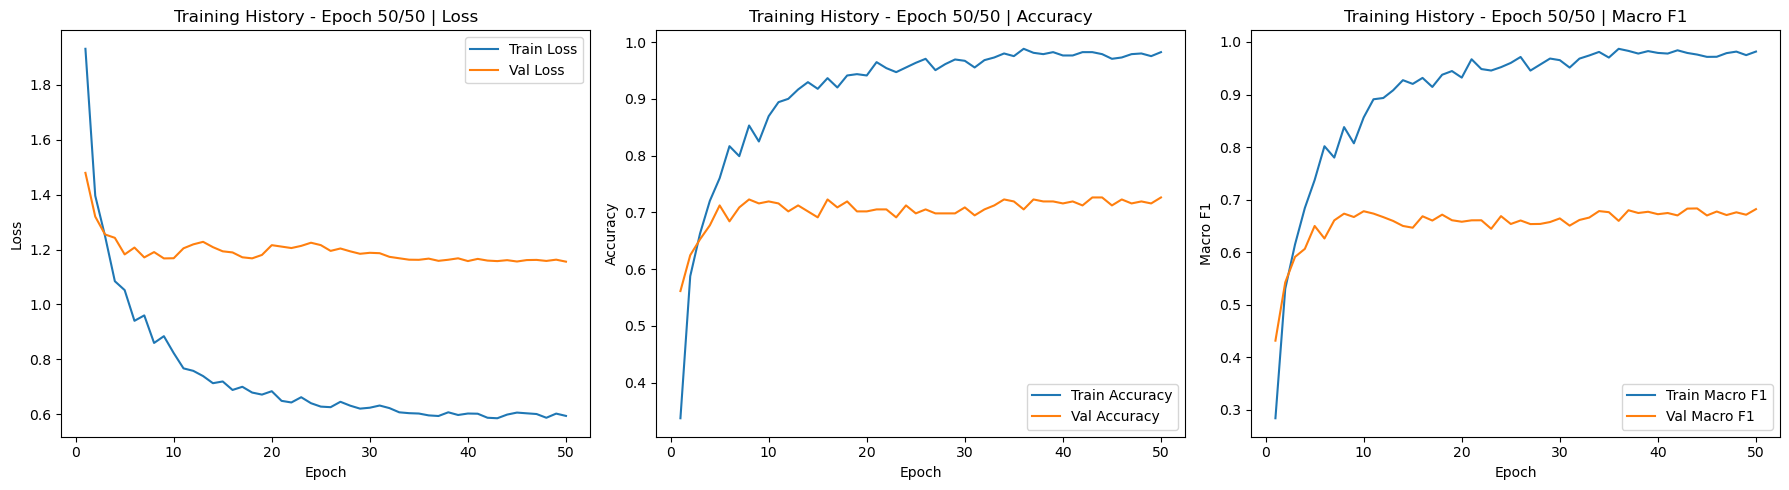

Epoch 50/50 | Train Loss: 0.5937 | Val Loss: 1.1559 | Train Acc: 0.9824 | Val Acc: 0.7263 | Train Macro F1: 0.9817 | Val Macro F1: 0.6820


In [44]:
best_model_state = None

for epoch in range(start_epoch, EPOCHS):
    train_loss, train_metrics = engine.train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        epoch=epoch + 1, total_epochs=EPOCHS
    )
    val_loss, val_metrics = engine.evaluate(
        model, val_loader, criterion, device,
        epoch=epoch + 1, total_epochs=EPOCHS
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    plot_training_history_live(history, epoch=epoch + 1, total_epochs=EPOCHS)

    save_checkpoint(
        RESNET18_LAST_CHECKPOINT_PATH,
        model=model,
        optimizer=optimizer,
        epoch=epoch + 1,
        best_val_f1=best_val_f1,
        history=history,
        scheduler=scheduler,
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_model_state = copy.deepcopy(model.state_dict())

        save_checkpoint(
            RESNET18_BEST_CHECKPOINT_PATH,
            model=model,
            optimizer=optimizer,
            epoch=epoch + 1,
            best_val_f1=best_val_f1,
            history=history,
            scheduler=scheduler,
        )

    scheduler.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Train Macro F1: {train_metrics['macro_f1']:.4f} | Val Macro F1: {val_metrics['macro_f1']:.4f}"
    )

In [54]:
model_resnet, _, _, _, _, _ = load_checkpoint(
    RESNET18_BEST_CHECKPOINT_PATH,
    ArtistStyleClassifier(num_classes=num_classes, pretrained=False).to(device),
    optimizer=None,
    map_location=device
)

test_loss_resnet, test_metrics_resnet = engine.evaluate(model_resnet, test_loader, criterion, device)

print("ResNet18 Test Results")
print("Test Loss:", round(test_loss_resnet, 4))
print("Test Accuracy:", round(test_metrics_resnet['accuracy'], 4))
print("Test Macro F1:", round(test_metrics_resnet['macro_f1'], 4))

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

ResNet18 Test Results
Test Loss: 1.0682
Test Accuracy: 0.7622
Test Macro F1: 0.7157



## EfficientNet

In [ ]:
efficientnet_model = EfficientNetClassifier(num_classes=num_classes, pretrained=True).to(device)

for name, param in efficientnet_model.backbone.named_parameters():
    if not any(name.startswith(layer) for layer in ['features.6', 'features.7', 'features.8']):
        param.requires_grad = False

criterion_eff = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_eff = torch.optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet_model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler_eff = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=EPOCHS)

In [50]:
start_epoch_eff = 0
best_val_f1_eff = -1.0
history_eff = init_history()

if RESUME_TRAINING_EFFICIENTNET and EFFICIENTNET_LAST_CHECKPOINT_PATH.exists():
    efficientnet_model, optimizer_eff, scheduler_eff, start_epoch_eff, best_val_f1_eff, loaded_history_eff = load_checkpoint(
        EFFICIENTNET_LAST_CHECKPOINT_PATH,
        efficientnet_model,
        optimizer=optimizer_eff,
        scheduler=scheduler_eff,
        map_location=device
    )
    if loaded_history_eff is not None:
        history_eff = loaded_history_eff

    print(f"Resumed EfficientNet from epoch {start_epoch_eff}")

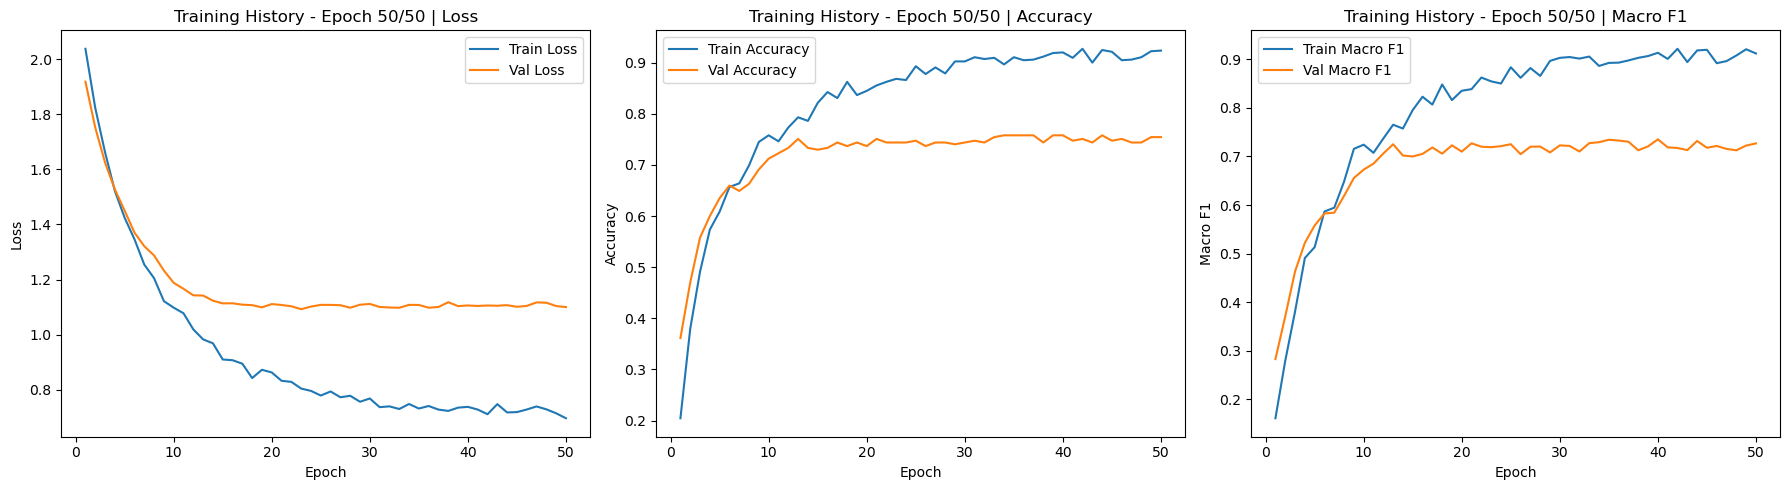

Epoch 50/50 | Train Loss: 0.6960 | Val Loss: 1.1000 | Train Acc: 0.9236 | Val Acc: 0.7544 | Train Macro F1: 0.9119 | Val Macro F1: 0.7267


In [51]:
best_efficientnet_state = None

for epoch in range(start_epoch_eff, EPOCHS):
    train_loss_eff, train_metrics_eff = engine.train_one_epoch(
        efficientnet_model, train_loader, criterion_eff, optimizer_eff, device,
        epoch=epoch + 1, total_epochs=EPOCHS
    )
    val_loss_eff, val_metrics_eff = engine.evaluate(
        efficientnet_model, val_loader, criterion_eff, device,
        epoch=epoch + 1, total_epochs=EPOCHS
    )

    history_eff["train_loss"].append(train_loss_eff)
    history_eff["val_loss"].append(val_loss_eff)
    history_eff["train_accuracy"].append(train_metrics_eff["accuracy"])
    history_eff["val_accuracy"].append(val_metrics_eff["accuracy"])
    history_eff["train_macro_f1"].append(train_metrics_eff["macro_f1"])
    history_eff["val_macro_f1"].append(val_metrics_eff["macro_f1"])

    plot_training_history_live(history_eff, epoch=epoch + 1, total_epochs=EPOCHS)

    save_checkpoint(
        EFFICIENTNET_LAST_CHECKPOINT_PATH,
        model=efficientnet_model,
        optimizer=optimizer_eff,
        epoch=epoch + 1,
        best_val_f1=best_val_f1_eff,
        history=history_eff,
        scheduler=scheduler_eff,
    )

    if val_metrics_eff["macro_f1"] > best_val_f1_eff:
        best_val_f1_eff = val_metrics_eff["macro_f1"]
        best_efficientnet_state = copy.deepcopy(efficientnet_model.state_dict())

        save_checkpoint(
            EFFICIENTNET_BEST_CHECKPOINT_PATH,
            model=efficientnet_model,
            optimizer=optimizer_eff,
            epoch=epoch + 1,
            best_val_f1=best_val_f1_eff,
            history=history_eff,
            scheduler=scheduler_eff,
        )

    scheduler_eff.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss_eff:.4f} | Val Loss: {val_loss_eff:.4f} | "
        f"Train Acc: {train_metrics_eff['accuracy']:.4f} | Val Acc: {val_metrics_eff['accuracy']:.4f} | "
        f"Train Macro F1: {train_metrics_eff['macro_f1']:.4f} | Val Macro F1: {val_metrics_eff['macro_f1']:.4f}"
    )

In [53]:
model_eff, _, _, _, _, _ = load_checkpoint(
    EFFICIENTNET_BEST_CHECKPOINT_PATH,
    EfficientNetClassifier(num_classes=num_classes, pretrained=False).to(device),
    optimizer=None,
    map_location=device
)

test_loss_eff, test_metrics_eff = engine.evaluate(model_eff, test_loader, criterion_eff, device)

print("EfficientNet Test Results")
print("Test Loss:", round(test_loss_eff, 4))
print("Test Accuracy:", round(test_metrics_eff['accuracy'], 4))
print("Test Macro F1:", round(test_metrics_eff['macro_f1'], 4))

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

EfficientNet Test Results
Test Loss: 1.0607
Test Accuracy: 0.7448
Test Macro F1: 0.7111
